
# Intelligent Asset Lifecycle Management
## Failure Prediction — Machine Learning Pipeline

This notebook follows the same overall architecture as the previous ML notebook:

**Load → Inspect → Clean → Feature Engineering → Train/Test Split → Preprocessing → Multiple ML Models → Compare → Best Model → Probability → Risk → Maintenance Recommendation**

### Dataset
Industrial machinery predictive-maintenance dataset (~24K rows).

### Prediction target
`failure_within_24h`

The model predicts whether a machine is likely to fail within the next 24 hours.

> **Important:** `rul_hours`, `failure_type`, and `estimated_repair_cost` are deliberately excluded from the failure model because they can leak information about the future/outcome. We will use them later for the lifecycle decision layer.


In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load Dataset

In [19]:

# Change this path if your CSV is stored somewhere else
DATA_PATH = "/content/drive/MyDrive/Zenesys/industrial_machine_predictive_maintenance.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (24042, 15)


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


## 3. Understand the Dataset

In [20]:

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Columns:
['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost']

Data types:
timestamp                   object
machine_id                   int64
machine_type                object
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode              object
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                object
estimated_repair_cost        int64
dtype: object

Missing values:
timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           8

failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

Percentage:
failure_within_24h
0    85.19258
1    14.80742
Name: proportion, dtype: float64


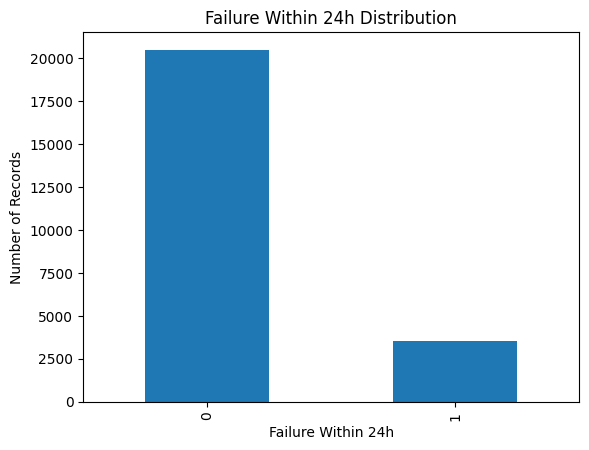

In [21]:

# Target distribution

print(df["failure_within_24h"].value_counts())
print("\nPercentage:")
print(df["failure_within_24h"].value_counts(normalize=True) * 100)

df["failure_within_24h"].value_counts().plot(
    kind="bar",
    title="Failure Within 24h Distribution"
)

plt.xlabel("Failure Within 24h")
plt.ylabel("Number of Records")
plt.show()



## 4. Basic Cleaning

We remove duplicate rows and the machine identifier.

We keep `machine_type` and `operating_mode` because they may contain useful information about different kinds of assets and operating conditions.


In [22]:

df = df.drop_duplicates().reset_index(drop=True)

# Identifier: useful for tracking a machine, but not useful as an ML feature
if "machine_id" in df.columns:
    df = df.drop(columns=["machine_id"])

print("New shape:", df.shape)


New shape: (24042, 14)



## 5. Feature Engineering

We create a couple of physically meaningful features.

### Temperature rise
`motor temperature - ambient temperature`

This tells us how much additional heat the motor is generating relative to the environment.

### Electrical load index
`current × RPM`

This is a simple proxy for operating/electrical stress.

These are engineered features rather than new measurements.


In [23]:

if {"temperature_motor", "ambient_temp"}.issubset(df.columns):
    df["temperature_rise"] = (
        df["temperature_motor"] - df["ambient_temp"]
    )

if {"current_phase_avg", "rpm"}.issubset(df.columns):
    df["electrical_load_index"] = (
        df["current_phase_avg"] * df["rpm"]
    )

df.head()


,timestamp,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost,temperature_rise,electrical_load_index
0,2024-01-01 00:00:00,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0,35.61,4390.590
1,2024-01-01 00:03:00,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0,30.38,4767.880
2,2024-01-01 00:21:00,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0,36.10,NaN
3,2024-01-01 00:45:00,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0,29.64,4169.216
4,2024-01-01 00:54:00,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0,30.59,3915.636



## 6. Select X and y

### Target

`failure_within_24h`

### Features excluded from the failure model

- `rul_hours` — future/remaining-life information
- `failure_type` — describes the failure outcome
- `estimated_repair_cost` — downstream information

Using these as predictors would make the model unrealistically powerful because it would have access to information that may only be known after/during the failure event.


In [24]:

TARGET = "failure_within_24h"

leakage_columns = [
    TARGET,
    "rul_hours",
    "failure_type",
    "estimated_repair_cost"
]

X = df.drop(
    columns=[c for c in leakage_columns if c in df.columns]
)

y = df[TARGET].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())


X shape: (24042, 12)
y shape: (24042,)

Features:
['timestamp', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'temperature_rise', 'electrical_load_index']


## 7. Train/Test Split

In [25]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 19233
Testing samples: 4809



## 8. Preprocessing

The dataset contains both numeric and categorical variables.

Numeric:
- temperature
- vibration
- pressure
- RPM
- etc.

Categorical:
- machine type
- operating mode

We:
1. Fill missing numeric values with the median.
2. Standardize numeric features.
3. Fill missing categorical values with the most frequent value.
4. One-hot encode categorical features.


In [26]:

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numeric features:
['vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp', 'temperature_rise', 'electrical_load_index']

Categorical features:
['timestamp', 'machine_type', 'operating_mode']


In [27]:

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created.")


Preprocessor created.


## 9. Define Machine Learning Models

In [28]:

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Models:")
for name in models:
    print("-", name)


Models:
- Logistic Regression
- SVM
- Decision Tree
- Random Forest


## 10. Train All Models and Compare Them

In [29]:

results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1 Score": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.960491,0.909091,0.814607,0.859259,0.990413
1,SVM,0.929715,0.700644,0.917135,0.794404,0.974579
2,Logistic Regression,0.919734,0.681111,0.860955,0.760546,0.958425
3,Decision Tree,0.920774,0.670443,0.914326,0.773619,0.945780



## 11. Select the Best Model

For this project, ROC-AUC is useful because the dataset is imbalanced: failures are less common than non-failures.

We will select the model with the highest ROC-AUC.


In [30]:

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best model:", best_model_name)


Best model: Random Forest


## 12. Detailed Evaluation

In [31]:

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test, best_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pred,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

print("ROC-AUC:",
      roc_auc_score(y_test, best_prob))


Confusion Matrix:
[[4039   58]
 [ 132  580]]

Classification Report:
              precision    recall  f1-score   support

  No Failure       0.97      0.99      0.98      4097
     Failure       0.91      0.81      0.86       712

    accuracy                           0.96      4809
   macro avg       0.94      0.90      0.92      4809
weighted avg       0.96      0.96      0.96      4809

ROC-AUC: 0.9904129631711885



## 13. Convert Failure Probability into an Asset Risk Level

The ML model gives us a probability.

We turn that into a human-readable asset risk level.

These thresholds are **business rules**, not learned by the ML model. They can later be tuned using the cost of downtime and maintenance.


In [32]:

def risk_level(probability):

    if probability >= 0.75:
        return "CRITICAL FAILURE RISK"

    elif probability >= 0.50:
        return "HIGH FAILURE RISK"

    elif probability >= 0.25:
        return "MODERATE FAILURE RISK"

    else:
        return "LOW FAILURE RISK"


# Example
example_probability = 0.82

print("Probability:", example_probability * 100, "%")
print("Risk:", risk_level(example_probability))


Probability: 82.0 %
Risk: CRITICAL FAILURE RISK



## 14. Maintenance Decision Engine

This is the first step beyond simple predictive maintenance.

The ML model predicts risk.

The decision engine converts that prediction into an action:

- Monitor
- Plan maintenance
- Schedule maintenance soon
- Urgent maintenance

Later, we will extend this to:

**Repair vs Upgrade vs Replace**


In [33]:

def maintenance_recommendation(
    failure_probability,
    hours_since_maintenance=None,
    rul_hours=None
):

    if failure_probability >= 0.75:
        return "URGENT MAINTENANCE"

    elif failure_probability >= 0.50:
        return "SCHEDULE MAINTENANCE SOON"

    elif rul_hours is not None and rul_hours < 100:
        return "PLAN MAINTENANCE"

    elif (
        hours_since_maintenance is not None
        and hours_since_maintenance > 500
    ):
        return "INSPECTION RECOMMENDED"

    else:
        return "MONITOR"


## 15. Test the System on One Asset

In [34]:

# Pick one asset from the test set
sample = X_test.iloc[[0]]

probability = best_model.predict_proba(sample)[0][1]

original_row = df.loc[sample.index[0]]

hours_since_maintenance = original_row.get(
    "hours_since_maintenance",
    None
)

rul = original_row.get(
    "rul_hours",
    None
)

print("======================================")
print("       ASSET INTELLIGENCE REPORT")
print("======================================")

print("Model:", best_model_name)

print(
    "Failure Probability: {:.2f}%".format(
        probability * 100
    )
)

print(
    "Risk Level:",
    risk_level(probability)
)

print(
    "Recommendation:",
    maintenance_recommendation(
        probability,
        hours_since_maintenance,
        rul
    )
)

print(
    "RUL:",
    round(rul, 2),
    "hours"
)

print(
    "Hours Since Maintenance:",
    round(hours_since_maintenance, 2)
)


       ASSET INTELLIGENCE REPORT
Model: Random Forest
Failure Probability: 0.33%
Risk Level: LOW FAILURE RISK
Recommendation: PLAN MAINTENANCE
RUL: 66.91 hours
Hours Since Maintenance: 29.48



## 16. Predict Risk for Every Test Asset


In [35]:

test_results = X_test.copy()

test_results["actual_failure"] = y_test.values

test_results["failure_probability"] = best_prob

test_results["risk_level"] = [
    risk_level(p)
    for p in best_prob
]

test_results["recommendation"] = [
    maintenance_recommendation(
        probability,
        df.loc[index, "hours_since_maintenance"],
        df.loc[index, "rul_hours"]
    )
    for probability, index in zip(
        best_prob,
        X_test.index
    )
]

test_results.head()


,timestamp,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,temperature_rise,electrical_load_index,actual_failure,failure_probability,risk_level,recommendation
16528,2024-01-11 11:36:24,Compressor,1.00,48.11,5.70,45.8,755.4,idle,29.48,8.7,39.41,4305.780,0,0.003333,LOW FAILURE RISK,PLAN MAINTENANCE
342,2024-01-05 05:46:31,CNC,4.34,62.52,16.82,69.5,2708.5,normal,15.92,8.5,54.02,45556.970,1,0.600000,HIGH FAILURE RISK,SCHEDULE MAINTENANCE SOON
20810,2024-01-04 20:47:00,Robotic Arm,0.98,35.87,5.38,44.4,348.9,normal,299.51,11.2,24.67,1877.082,0,0.006667,LOW FAILURE RISK,PLAN MAINTENANCE
1787,2024-01-08 23:42:14,CNC,0.89,40.88,5.34,22.3,871.9,idle,82.77,10.9,29.98,4655.946,0,0.000000,LOW FAILURE RISK,PLAN MAINTENANCE
10553,2024-01-11 05:30:00,Pump,0.65,58.75,4.36,18.4,467.8,idle,454.77,13.8,44.95,2039.608,0,0.570000,HIGH FAILURE RISK,SCHEDULE MAINTENANCE SOON


In [36]:

print("Risk distribution:")
print(
    test_results["risk_level"].value_counts()
)

print("\nRecommendation distribution:")
print(
    test_results["recommendation"].value_counts()
)


Risk distribution:
risk_level
LOW FAILURE RISK         3898
CRITICAL FAILURE RISK     360
HIGH FAILURE RISK         284
MODERATE FAILURE RISK     267
Name: count, dtype: int64

Recommendation distribution:
recommendation
PLAN MAINTENANCE             4165
URGENT MAINTENANCE            360
SCHEDULE MAINTENANCE SOON     284
Name: count, dtype: int64



# 17. Inspect High-Risk Assets

This is the type of output that can eventually become your hackathon dashboard.


In [37]:

high_risk_assets = test_results[
    test_results["failure_probability"] >= 0.50
].sort_values(
    "failure_probability",
    ascending=False
)

high_risk_assets.head(20)


,timestamp,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,temperature_rise,electrical_load_index,actual_failure,failure_probability,risk_level,recommendation
22541,2024-01-10 19:38:19,Robotic Arm,1.74,81.29,7.99,42.3,303.9,normal,157.77,12.8,68.49,2428.161,1,0.996667,CRITICAL FAILURE RISK,URGENT MAINTENANCE
12591,2024-01-06 21:30:00,Compressor,2.83,91.79,20.99,112.3,1445.1,normal,534.05,15.0,76.79,30332.649,1,0.993333,CRITICAL FAILURE RISK,URGENT MAINTENANCE
23356,2024-01-06 17:11:21,Robotic Arm,1.72,73.22,7.97,45.2,303.3,normal,53.12,10.7,62.52,2417.301,1,0.993333,CRITICAL FAILURE RISK,URGENT MAINTENANCE
19643,2024-01-05 18:18:50,Robotic Arm,1.29,73.50,7.68,41.1,312.9,normal,46.97,9.0,64.50,2403.072,1,0.993333,CRITICAL FAILURE RISK,URGENT MAINTENANCE
23304,2024-01-06 02:21:21,Robotic Arm,0.50,56.53,3.10,18.8,137.0,idle,38.28,14.3,42.23,424.700,1,0.990000,CRITICAL FAILURE RISK,URGENT MAINTENANCE
23341,2024-01-06 13:32:21,Robotic Arm,1.25,68.31,7.85,43.0,302.5,normal,49.47,12.1,56.21,2374.625,1,0.990000,CRITICAL FAILURE RISK,URGENT MAINTENANCE
21939,2024-01-03 19:28:00,Robotic Arm,1.68,74.33,7.77,41.3,299.6,normal,140.25,14.8,59.53,2327.892,1,0.990000,CRITICAL FAILURE RISK,URGENT MAINTENANCE
22527,2024-01-10 16:01:19,Robotic Arm,1.51,69.51,7.73,39.8,310.5,normal,154.15,13.9,55.61,2400.165,1,0.986667,CRITICAL FAILURE RISK,URGENT MAINTENANCE
12594,2024-01-06 22:19:00,Compressor,2.87,90.55,18.81,100.3,1559.8,normal,534.86,17.0,73.55,29339.838,1,0.983333,CRITICAL FAILURE RISK,URGENT MAINTENANCE
23337,2024-01-06 12:12:21,Robotic Arm,1.66,71.94,8.04,46.4,299.5,normal,48.13,9.4,62.54,2407.980,1,0.983333,CRITICAL FAILURE RISK,URGENT MAINTENANCE



# 18. Save Predictions

The generated CSV can later be consumed by a Flask/FastAPI backend or dashboard.


In [39]:

OUTPUT_PATH = "/content/drive/MyDrive/Zenesys/asset_failure_predictions.csv"

test_results.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Saved:", OUTPUT_PATH)


Saved: /content/drive/MyDrive/Zenesys/asset_failure_predictions.csv


In [40]:
# Predictions on training data
y_train_pred = best_model.predict(X_train)

# Predictions on test data
y_test_pred = best_model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Difference       :", train_accuracy - test_accuracy)

Training Accuracy: 1.0
Testing Accuracy : 0.9604907465169474
Difference       : 0.039509253483052564


In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())

CV scores: [0.89415679 0.93595342 0.93261231 0.9155574  0.89912646]
Mean CV accuracy: 0.9154812766135597
Std: 0.01693989844227679


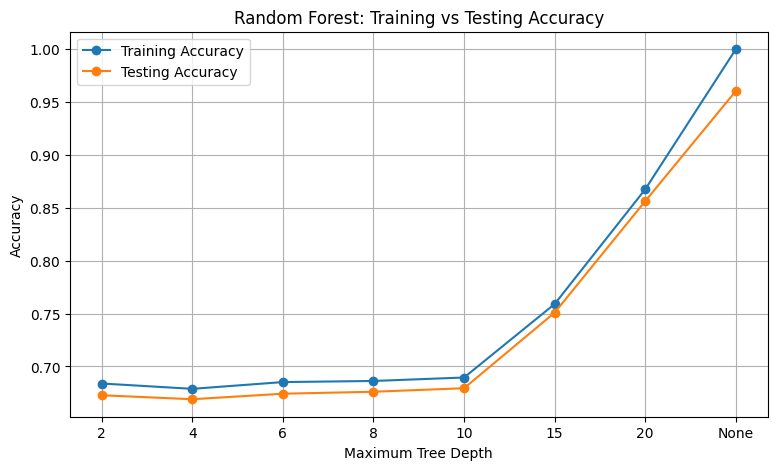

In [43]:
max_depths = [2, 4, 6, 8, 10, 15, 20, None]

train_scores = []
test_scores = []

for depth in max_depths:

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=depth,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", rf)
    ])

    pipeline.fit(X_train, y_train)

    train_scores.append(
        accuracy_score(y_train, pipeline.predict(X_train))
    )

    test_scores.append(
        accuracy_score(y_test, pipeline.predict(X_test))
    )

plt.figure(figsize=(9, 5))

plt.plot(
    range(len(max_depths)),
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    range(len(max_depths)),
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xticks(
    range(len(max_depths)),
    [str(x) for x in max_depths]
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Random Forest: Training vs Testing Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 150, 200, 300],
    "model__max_depth": [10, 15, 20, 25, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=20,          # only 20 combinations
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV accuracy:")
print(random_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_

train_accuracy = accuracy_score(
    y_train,
    best_rf.predict(X_train)
)

test_accuracy = accuracy_score(
    y_test,
    best_rf.predict(X_test)
)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Gap              :", train_accuracy - test_accuracy)

In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_rf.predict(X_test),
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)


# Next Stage — Full Asset Lifecycle Intelligence

The failure model above is only the first layer.

Next we can build:

### Model 2 — Remaining Useful Life

**Input → sensor/operational data**

**Output → predicted RUL in hours**

### Lifecycle Decision Engine

Combine:

- Failure probability
- Predicted RUL
- Maintenance history
- Repair cost
- Asset criticality
- Utilization

Then produce:

**MONITOR / MAINTAIN / REPAIR / UPGRADE / REPLACE**

That will turn this from a predictive-maintenance project into a complete **Intelligent Asset Lifecycle Management** system.
